# Anomaly Detection

## import libraries

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


## get data

In [4]:
DATA_PATH = Path("../data/raw/iot_sensor_data.csv")
GROUND_TRUTH_PATH = Path("../data/ground_truth/anomalies.csv")

df = pd.read_csv(DATA_PATH)
ground_truth = pd.read_csv(GROUND_TRUTH_PATH)

df["timestamp"] = pd.to_datetime(df["timestamp"])

ground_truth["timestamp"] = pd.to_datetime(
    ground_truth["timestamp"]
)

print("Data:", df.shape)
print("Ground truth:", ground_truth.shape)

Data: (432000, 11)
Ground truth: (1690, 5)


## detector: Rule-Based Detection

In [5]:
df["humidity_rule_anomaly"] = (
    (df["humidity"] < 0) |
    (df["humidity"] > 100)
)

In [6]:
df["temperature_rule_anomaly"] = (
    (df["temperature"] < -20) |
    (df["temperature"] > 60)
)

## Statistical Detection

In [7]:
df = df.sort_values(
    ["device_id", "timestamp"]
)

df["temperature_rolling_mean"] = (
    df.groupby("device_id")["temperature"]
    .transform(
        lambda x: x.rolling(
            window=30,
            min_periods=10
        ).mean()
    )
)

In [8]:
df["temperature_rolling_std"] = (
    df.groupby("device_id")["temperature"]
      .transform(
          lambda x: x.rolling(
              window=30,
              min_periods=10
          ).std()
      )
)

In [9]:
df["temperature_zscore"] = (
    (
        df["temperature"]
        - df["temperature_rolling_mean"]
    )
    /
    df["temperature_rolling_std"]
)

In [10]:
# We use |z| > 3 as an initial statistical baseline and later evaluate whether this threshold is appropriate for the dataset.
df["temperature_stat_anomaly"] = (
    df["temperature_zscore"].abs() > 3
)

## Visualization

In [11]:
sample_device = "DEV_007"

plot_df = df[
    df["device_id"] == sample_device
].copy()

In [12]:
plot_df = plot_df[
    plot_df["timestamp"] < (
        plot_df["timestamp"].min()
        + pd.Timedelta(days=3)
    )
]

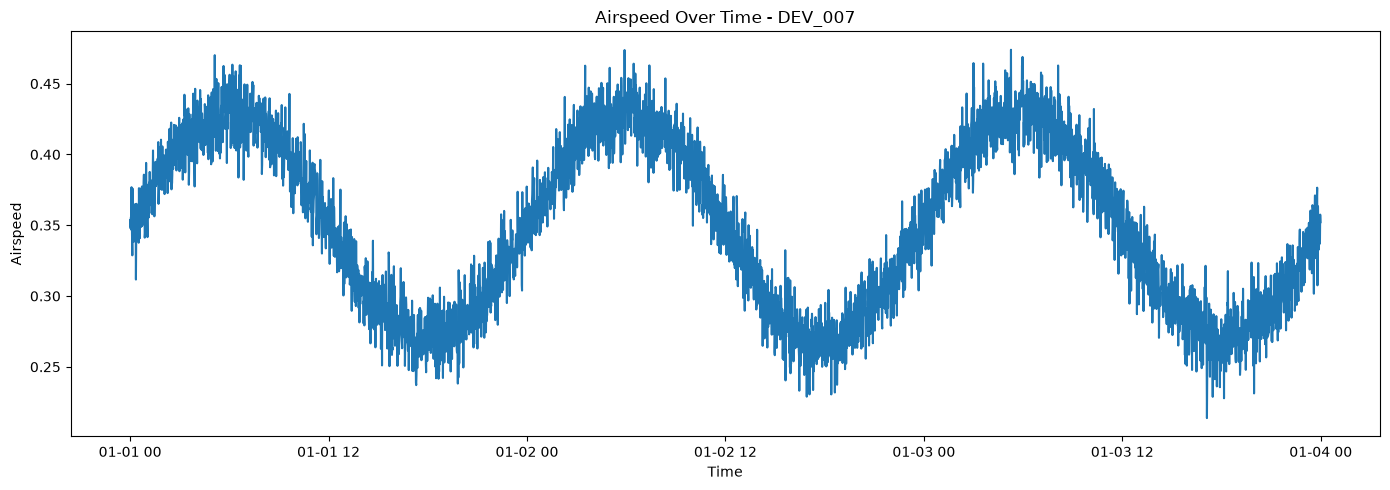

In [13]:
plt.figure(figsize=(14, 5))

plt.plot(
    plot_df["timestamp"],
    plot_df["airspeed"],
    label="Airspeed"
)

plt.title("Airspeed Over Time - DEV_007")
plt.xlabel("Time")
plt.ylabel("Airspeed")

plt.tight_layout()
plt.show()

In [14]:
# just for showing the drift

drift_truth = ground_truth[
    (ground_truth["anomaly_type"] == "drift") &
    (ground_truth["device_id"] == "DEV_007")
]

drift_truth[
    ["timestamp", "device_id", "sensor", "anomaly_type"]
].head()

,timestamp,device_id,sensor,anomaly_type
1190,2026-01-30 15:40:00,DEV_007,airspeed,drift
1191,2026-01-30 15:41:00,DEV_007,airspeed,drift
1192,2026-01-30 15:42:00,DEV_007,airspeed,drift
1193,2026-01-30 15:43:00,DEV_007,airspeed,drift
1194,2026-01-30 15:44:00,DEV_007,airspeed,drift


In [15]:
drift_truth[
    ["timestamp", "device_id", "sensor", "anomaly_type"]
].tail()

,timestamp,device_id,sensor,anomaly_type
1685,2026-01-30 23:55:00,DEV_007,airspeed,drift
1686,2026-01-30 23:56:00,DEV_007,airspeed,drift
1687,2026-01-30 23:57:00,DEV_007,airspeed,drift
1688,2026-01-30 23:58:00,DEV_007,airspeed,drift
1689,2026-01-30 23:59:00,DEV_007,airspeed,drift


In [16]:
drift_start = drift_truth["timestamp"].min()
drift_end = drift_truth["timestamp"].max()

print("Drift start:", drift_start)
print("Drift end:", drift_end)

Drift start: 2026-01-30 15:40:00
Drift end: 2026-01-30 23:59:00


In [17]:
drift_data = df[
    (df["device_id"] == "DEV_007") &
    (df["timestamp"] >= drift_start - pd.Timedelta(minutes=30)) &
    (df["timestamp"] <= drift_end + pd.Timedelta(minutes=30))
].copy()

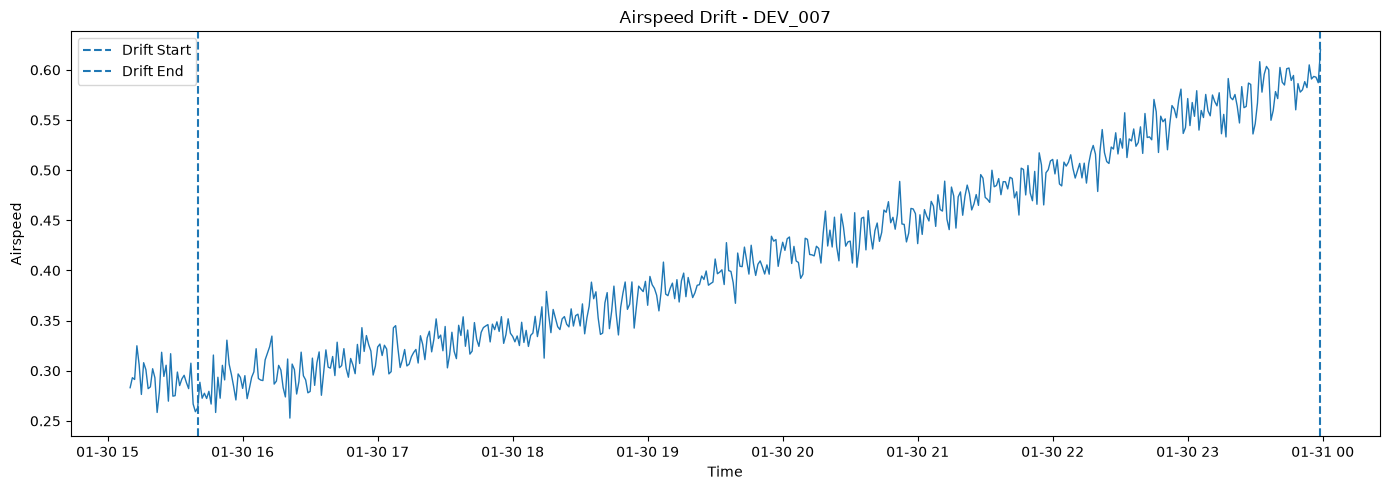

In [18]:
plt.figure(figsize=(14, 5))

plt.plot(
    drift_data["timestamp"],
    drift_data["airspeed"],
    linewidth=1
)

plt.axvline(
    drift_start,
    linestyle="--",
    label="Drift Start"
)

plt.axvline(
    drift_end,
    linestyle="--",
    label="Drift End"
)

plt.title("Airspeed Drift - DEV_007")
plt.xlabel("Time")
plt.ylabel("Airspeed")
plt.legend()

plt.tight_layout()
plt.show()

## Feature Engineering

In [19]:
model_df = df.copy()

model_df = model_df.sort_values(
    ["device_id", "timestamp"]
).reset_index(drop=True)

In [20]:
def add_rolling_features(
    data,
    sensor,
    window=30
):
    group = data.groupby("device_id")[sensor]

    data[f"{sensor}_rolling_mean"] = (
        group.transform(
            lambda x: x.rolling(
                window=window,
                min_periods=10
            ).mean()
        )
    )

    data[f"{sensor}_rolling_std"] = (
        group.transform(
            lambda x: x.rolling(
                window=window,
                min_periods=10
            ).std()
        )
    )

    data[f"{sensor}_deviation"] = (
        data[sensor]
        - data[f"{sensor}_rolling_mean"]
    )

    data[f"{sensor}_rolling_zscore"] = (
        data[f"{sensor}_deviation"]
        / data[f"{sensor}_rolling_std"]
    )

    return data

In [21]:
for sensor in [
    "temperature",
    "humidity",
    "co2",
    "airspeed",
    "light",
]:
    model_df = add_rolling_features(
        model_df,
        sensor
    )

In [22]:
for sensor in [
    "temperature",
    "humidity",
    "co2",
    "airspeed",
    "light",
]:
    model_df[f"{sensor}_diff"] = (
        model_df.groupby("device_id")[sensor]
        .diff()
    )

In [23]:
model_df[
    [
        "device_id",
        "timestamp",
        "temperature",
        "temperature_rolling_mean",
        "temperature_rolling_std",
        "temperature_deviation",
        "temperature_rolling_zscore",
        "temperature_diff",
    ]
].head(15)

,device_id,timestamp,temperature,temperature_rolling_mean,temperature_rolling_std,temperature_deviation,temperature_rolling_zscore,temperature_diff
0,DEV_001,2026-01-01 00:00:00,23.922834,NaN,NaN,NaN,NaN,NaN
1,DEV_001,2026-01-01 00:01:00,24.386213,NaN,NaN,NaN,NaN,0.463379
2,DEV_001,2026-01-01 00:02:00,24.449512,NaN,NaN,NaN,NaN,0.063298
3,DEV_001,2026-01-01 00:03:00,23.742381,NaN,NaN,NaN,NaN,-0.707131
4,DEV_001,2026-01-01 00:04:00,23.920363,NaN,NaN,NaN,NaN,0.177982
5,DEV_001,2026-01-01 00:05:00,24.293636,NaN,NaN,NaN,NaN,0.373272
6,DEV_001,2026-01-01 00:06:00,24.198381,NaN,NaN,NaN,NaN,-0.095255
7,DEV_001,2026-01-01 00:07:00,24.289005,NaN,NaN,NaN,NaN,0.090624
8,DEV_001,2026-01-01 00:08:00,24.095707,NaN,NaN,NaN,NaN,-0.193299
9,DEV_001,2026-01-01 00:09:00,24.544577,24.184261,0.259313,0.360316,1.389502,0.448870


In [24]:
feature_columns = [
    column
    for column in model_df.columns
    if any(
        pattern in column
        for pattern in [
            "_rolling_mean",
            "_rolling_std",
            "_deviation",
            "_rolling_zscore",
            "_diff",
        ]
    )
]

len(feature_columns), feature_columns

(25,
 ['temperature_rolling_mean',
  'temperature_rolling_std',
  'temperature_deviation',
  'temperature_rolling_zscore',
  'humidity_rolling_mean',
  'humidity_rolling_std',
  'humidity_deviation',
  'humidity_rolling_zscore',
  'co2_rolling_mean',
  'co2_rolling_std',
  'co2_deviation',
  'co2_rolling_zscore',
  'airspeed_rolling_mean',
  'airspeed_rolling_std',
  'airspeed_deviation',
  'airspeed_rolling_zscore',
  'light_rolling_mean',
  'light_rolling_std',
  'light_deviation',
  'light_rolling_zscore',
  'temperature_diff',
  'humidity_diff',
  'co2_diff',
  'airspeed_diff',
  'light_diff'])

In [25]:
model_df[feature_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_rolling_mean,431909.0,2.417112e+01,2.551404,19.266809,21.810778,24.174282,26.529566,29.037006
temperature_rolling_std,431909.0,2.673107e-01,0.076365,0.124255,0.239514,0.263859,0.289359,2.760589
temperature_deviation,431410.0,1.535293e-04,0.300750,-1.300082,-0.200668,-0.000167,0.200216,14.536472
temperature_rolling_zscore,431410.0,7.338812e-04,1.079352,-3.981050,-0.766953,-0.000642,0.767894,5.274935
humidity_rolling_mean,431910.0,6.480479e+01,5.754637,54.653788,59.290370,64.802665,70.318910,75.398236
humidity_rolling_std,431910.0,1.042301e+00,0.534750,0.000000,0.920560,1.010432,1.103280,13.021465
humidity_deviation,431910.0,-2.606748e-04,1.187155,-5.255472,-0.712491,-0.003527,0.705231,68.732368
humidity_rolling_zscore,431728.0,3.258212e-04,1.019392,-5.294651,-0.704575,-0.004093,0.704468,5.294651
co2_rolling_mean,431910.0,8.027883e+02,134.652124,548.643534,683.215860,802.154966,920.740302,1064.856083
co2_rolling_std,431910.0,2.067513e+01,7.464841,9.795004,18.576026,20.361845,22.217880,271.703459


In [26]:
model_df[
    [
        "timestamp",
        "device_id",
        "temperature",
        "temperature_rolling_mean",
        "temperature_rolling_std",
        "temperature_deviation",
        "temperature_rolling_zscore",
        "temperature_diff",
    ]
].head(40)

,timestamp,device_id,temperature,temperature_rolling_mean,temperature_rolling_std,temperature_deviation,temperature_rolling_zscore,temperature_diff
0,2026-01-01 00:00:00,DEV_001,23.922834,NaN,NaN,NaN,NaN,NaN
1,2026-01-01 00:01:00,DEV_001,24.386213,NaN,NaN,NaN,NaN,0.463379
2,2026-01-01 00:02:00,DEV_001,24.449512,NaN,NaN,NaN,NaN,0.063298
3,2026-01-01 00:03:00,DEV_001,23.742381,NaN,NaN,NaN,NaN,-0.707131
4,2026-01-01 00:04:00,DEV_001,23.920363,NaN,NaN,NaN,NaN,0.177982
5,2026-01-01 00:05:00,DEV_001,24.293636,NaN,NaN,NaN,NaN,0.373272
6,2026-01-01 00:06:00,DEV_001,24.198381,NaN,NaN,NaN,NaN,-0.095255
7,2026-01-01 00:07:00,DEV_001,24.289005,NaN,NaN,NaN,NaN,0.090624
8,2026-01-01 00:08:00,DEV_001,24.095707,NaN,NaN,NaN,NaN,-0.193299
9,2026-01-01 00:09:00,DEV_001,24.544577,24.184261,0.259313,0.360316,1.389502,0.448870


## Rolling Slope

In [27]:
def rolling_slope(data, sensor, window=30):
    def calculate_slope(values):
        if values.isna().any():
            return np.nan

        x = np.arange(len(values))

        return np.polyfit(
            x,
            values,
            1
        )[0]

    return (
        data.groupby("device_id")[sensor]
        .transform(
            lambda x: x.rolling(
                window=window,
                min_periods=10
            ).apply(
                calculate_slope,
                raw=False
            )
        )
    )

In [28]:
model_df["airspeed_rolling_slope"] = rolling_slope(
    model_df,
    "airspeed",
    window=30
)

In [29]:
model_df[
    [
        "timestamp",
        "device_id",
        "airspeed",
        "airspeed_diff",
        "airspeed_rolling_slope",
    ]
].iloc[8:20]

,timestamp,device_id,airspeed,airspeed_diff,airspeed_rolling_slope
8,2026-01-01 00:08:00,DEV_001,0.363627,0.008973,NaN
9,2026-01-01 00:09:00,DEV_001,0.376809,0.013182,-0.000128
10,2026-01-01 00:10:00,DEV_001,0.355659,-0.021150,-0.000183
11,2026-01-01 00:11:00,DEV_001,0.348873,-0.006786,-0.000468
12,2026-01-01 00:12:00,DEV_001,0.353360,0.004487,-0.000478
13,2026-01-01 00:13:00,DEV_001,0.365515,0.012156,-0.000122
14,2026-01-01 00:14:00,DEV_001,0.340290,-0.025225,-0.000519
15,2026-01-01 00:15:00,DEV_001,0.345253,0.004963,-0.000664
16,2026-01-01 00:16:00,DEV_001,0.383784,0.038531,0.000006
17,2026-01-01 00:17:00,DEV_001,0.343760,-0.040024,-0.000227


## FEATURE MATRIX

In [30]:
feature_columns.append(
    "airspeed_rolling_slope"
)

In [31]:
X = model_df[feature_columns].copy()

print("Number of features:", len(feature_columns))
print("Feature matrix shape:", X.shape)
print("Missing values:", X.isna().sum().sum())

Number of features: 26
Feature matrix shape: (432000, 26)
Missing values: 4123


In [32]:
valid_mask = X.notna().all(axis=1)

X_clean = X.loc[valid_mask].copy()

print("Original rows:", len(X))
print("Rows used for modeling:", len(X_clean))
print("Rows removed:", len(X) - len(X_clean))

Original rows: 432000
Rows used for modeling: 430730
Rows removed: 1270


In [33]:
print(
    "Missing values after cleaning:",
    X_clean.isna().sum().sum()
)

Missing values after cleaning: 0


In [34]:
X_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_rolling_mean,430730.0,2.417135e+01,2.551381,19.266809,21.811353,2.417425e+01,26.529583,29.037006
temperature_rolling_std,430730.0,2.673142e-01,0.076359,0.124255,0.239524,2.638593e-01,0.289362,2.760589
temperature_deviation,430730.0,1.409233e-04,0.300751,-1.300082,-0.200670,-1.536487e-04,0.200172,14.536472
temperature_rolling_zscore,430730.0,6.730272e-04,1.079307,-3.981050,-0.766966,-6.050590e-04,0.767713,5.274935
humidity_rolling_mean,430730.0,6.480468e+01,5.754110,54.653788,59.291957,6.480291e+01,70.317721,75.398236
humidity_rolling_std,430730.0,1.042743e+00,0.534742,0.000001,0.920651,1.010485e+00,1.103323,13.021465
humidity_deviation,430730.0,-2.926671e-04,1.184840,-5.255472,-0.712682,-4.052841e-03,0.705770,68.732368
humidity_rolling_zscore,430730.0,3.919456e-04,1.019405,-5.294651,-0.704501,-4.052995e-03,0.704601,5.294651
co2_rolling_mean,430730.0,8.027773e+02,134.668025,548.643534,683.185562,8.021602e+02,920.762494,1064.856083
co2_rolling_std,430730.0,2.067497e+01,7.473897,9.795004,18.575062,2.036083e+01,22.217032,271.703459


## ISOLATION FOREST*
Unsupervised Anomaly Detection

In [35]:
from sklearn.ensemble import IsolationForest

In [36]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination="auto", # what percent of data is outlier?
    random_state=42,
    n_jobs=-1
)

In [37]:
iso_forest.fit(X_clean)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [38]:
predictions = iso_forest.predict(X_clean)

In [39]:
model_df.loc[
    X_clean.index,
    "isolation_forest_prediction"
] = predictions

In [40]:
model_df["isolation_forest_anomaly"] = (
    model_df["isolation_forest_prediction"] == -1
)

In [41]:
model_df[
    "isolation_forest_anomaly"
].value_counts()

isolation_forest_anomaly
False    410032
True      21968
Name: count, dtype: int64

In [42]:
model_df[
    "isolation_forest_anomaly"
].mean()

np.float64(0.05085185185185185)

### EVALUTAION >> Ground Truth VS Prediction

In [43]:
evaluation_df = model_df.loc[
    X_clean.index,
    [
        "timestamp",
        "device_id",
        "location_id",
        "isolation_forest_anomaly",
    ]
].copy()

In [44]:
ground_truth_keys = (
    ground_truth[
        [
            "timestamp",
            "device_id",
        ]
    ]
    .drop_duplicates()
    .assign(ground_truth_anomaly=True)
)

ground_truth_keys.ground_truth_anomaly.value_counts()

ground_truth_anomaly
True    1689
Name: count, dtype: int64

In [45]:
evaluation_df = evaluation_df.merge(
    ground_truth_keys,
    on=["timestamp", "device_id"],
    how="left",
)

In [46]:
evaluation_df["ground_truth_anomaly"] = (
    evaluation_df["ground_truth_anomaly"]
    .fillna(False)
)

In [47]:
evaluation_df.ground_truth_anomaly.value_counts()

ground_truth_anomaly
False    429725
True       1005
Name: count, dtype: int64

In [48]:
evaluation_df[
    [
        "timestamp",
        "device_id",
        "isolation_forest_anomaly",
        "ground_truth_anomaly",
    ]
].head(20)

,timestamp,device_id,isolation_forest_anomaly,ground_truth_anomaly
0,2026-01-01 00:09:00,DEV_001,False,False
1,2026-01-01 00:10:00,DEV_001,False,False
2,2026-01-01 00:11:00,DEV_001,False,False
3,2026-01-01 00:12:00,DEV_001,False,False
4,2026-01-01 00:13:00,DEV_001,False,False
5,2026-01-01 00:14:00,DEV_001,False,False
6,2026-01-01 00:15:00,DEV_001,False,False
7,2026-01-01 00:16:00,DEV_001,False,False
8,2026-01-01 00:17:00,DEV_001,False,False
9,2026-01-01 00:18:00,DEV_001,False,False


In [49]:
tp = (
    evaluation_df["isolation_forest_anomaly"]
    & evaluation_df["ground_truth_anomaly"]
).sum()

fp = (
    evaluation_df["isolation_forest_anomaly"]
    & ~evaluation_df["ground_truth_anomaly"]
).sum()

fn = (
    ~evaluation_df["isolation_forest_anomaly"]
    & evaluation_df["ground_truth_anomaly"]
).sum()

tn = (
    ~evaluation_df["isolation_forest_anomaly"]
    & ~evaluation_df["ground_truth_anomaly"]
).sum()

print("True Positives :", tp)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Negatives :", tn)

True Positives : 150
False Positives: 21968
False Negatives: 855
True Negatives : 408762


### FALSE POSITIVE Analysis

In [50]:
false_positive_df = evaluation_df[
    evaluation_df["isolation_forest_anomaly"]
    & ~evaluation_df["ground_truth_anomaly"]
].copy()

print("False positives:", len(false_positive_df))

False positives: 21968


In [53]:
fp_by_device = (
    false_positive_df
    .groupby("device_id")
    .size()
    .sort_values(ascending=False)
)

fp_by_device

device_id
DEV_006    2273
DEV_003    2271
DEV_005    2213
DEV_002    2213
DEV_010    2196
DEV_007    2190
DEV_001    2183
DEV_008    2181
DEV_009    2147
DEV_004    2101
dtype: int64

In [54]:
predicted_anomaly_by_device = (
    evaluation_df[
        evaluation_df["isolation_forest_anomaly"]
    ]
    .groupby("device_id")
    .size()
    .sort_values(ascending=False)
)

predicted_anomaly_by_device

device_id
DEV_006    2273
DEV_003    2271
DEV_005    2213
DEV_002    2213
DEV_010    2196
DEV_007    2190
DEV_001    2183
DEV_008    2181
DEV_009    2147
DEV_004    2101
dtype: int64

In [55]:
actual_anomaly_by_device = (
    evaluation_df[
        evaluation_df["ground_truth_anomaly"]
    ]
    .groupby("device_id")
    .size()
    .sort_values(ascending=False)
)

actual_anomaly_by_device

device_id
DEV_007    507
DEV_002    186
DEV_005    132
DEV_003    131
DEV_009     12
DEV_006     11
DEV_010     10
DEV_001      7
DEV_008      6
DEV_004      3
dtype: int64

In [56]:
false_positive_df["hour"] = (
    false_positive_df["timestamp"].dt.hour
)

fp_by_hour = (
    false_positive_df
    .groupby("hour")
    .size()
)

fp_by_hour

hour
0      855
1      889
2      943
3      993
4      967
5     1279
6     1337
7     1237
8     1068
9      872
10     881
11     989
12     842
13     771
14     804
15     809
16     904
17     968
18    1032
19     832
20     736
21     587
22     625
23     748
dtype: int64

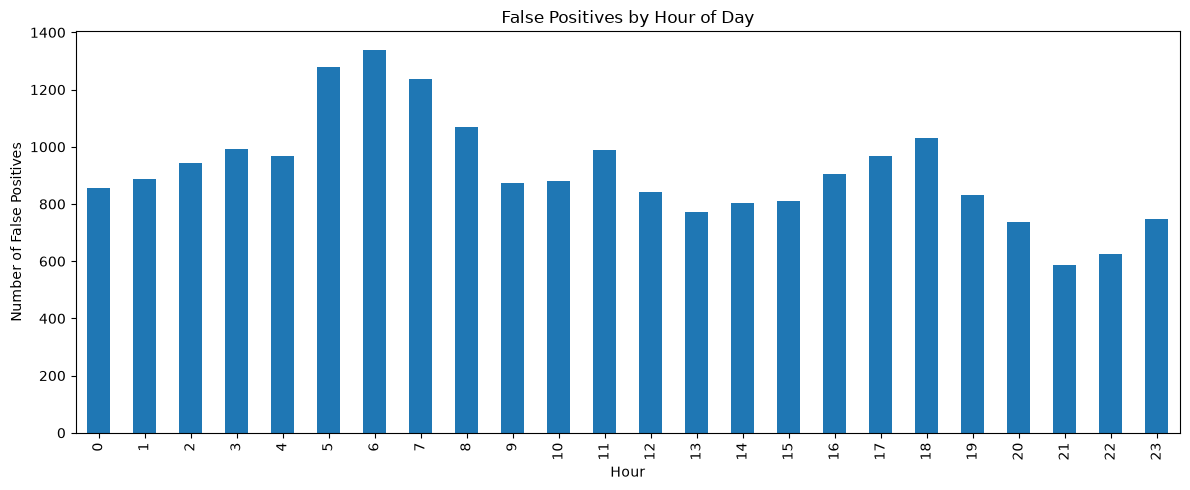

In [57]:
plt.figure(figsize=(12, 5))

fp_by_hour.plot(
    kind="bar"
)

plt.title(
    "False Positives by Hour of Day"
)

plt.xlabel("Hour")
plt.ylabel("Number of False Positives")

plt.tight_layout()
plt.show()

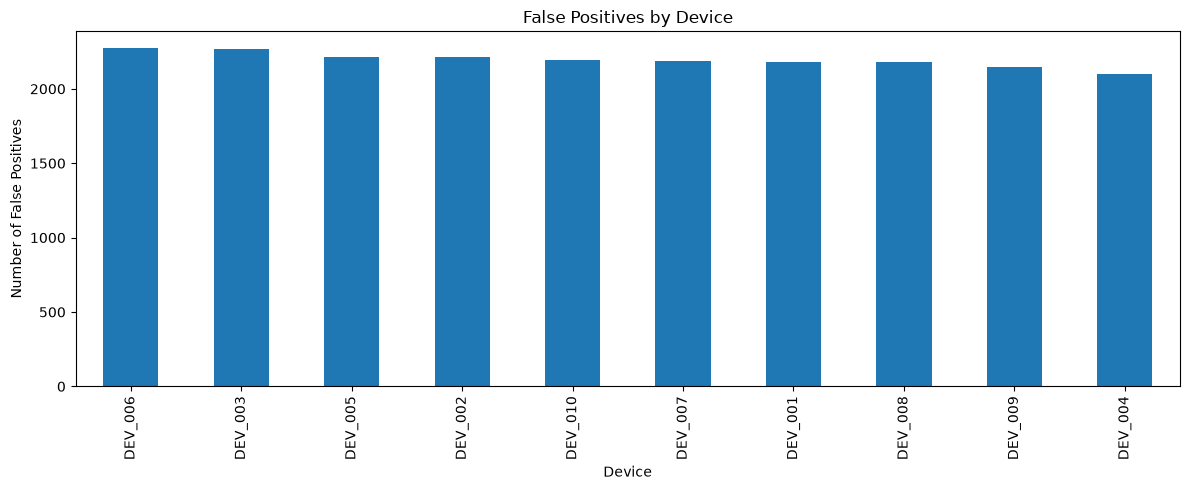

In [58]:
plt.figure(figsize=(12, 5))

fp_by_device.plot(
    kind="bar"
)

plt.title(
    "False Positives by Device"
)

plt.xlabel("Device")
plt.ylabel("Number of False Positives")

plt.tight_layout()
plt.show()

## ISOLATION FOREST SCORE
🔴 ⏬SCORE >> ANOMALUS⏫

🟢 ⏫SCORE >> NORMAL⏫

In [64]:
model_df.loc[
    X_clean.index,
    "isolation_forest_score"
] = iso_forest.decision_function(X_clean)

In [66]:
model_df.loc[
    X_clean.index,
    [
        "timestamp",
        "device_id",
        "isolation_forest_score",
        "isolation_forest_anomaly",
    ]
].sort_values(
    "isolation_forest_score"
).head(20)

,timestamp,device_id,isolation_forest_score,isolation_forest_anomaly
1711,2026-01-02 04:31:00,DEV_001,-0.107731,True
417653,2026-01-21 00:53:00,DEV_010,-0.107139,True
147923,2026-01-13 17:23:00,DEV_004,-0.098673,True
411444,2026-01-16 17:24:00,DEV_010,-0.094938,True
427504,2026-01-27 21:04:00,DEV_010,-0.092197,True
206483,2026-01-24 09:23:00,DEV_005,-0.091413,True
427410,2026-01-27 19:30:00,DEV_010,-0.090483,True
119145,2026-01-23 17:45:00,DEV_003,-0.089287,True
154223,2026-01-18 02:23:00,DEV_004,-0.088394,True
416345,2026-01-20 03:05:00,DEV_010,-0.087685,True


In [67]:
print("Predicted anomalies:",
      evaluation_df["isolation_forest_anomaly"].sum())

print("True Positives:", tp)
print("False Positives:", fp)

print("TP + FP:", tp + fp)

Predicted anomalies: 21968
True Positives: 150
False Positives: 21968
TP + FP: 22118


In [68]:
# MISTAKE HAPPENED HERE, NEED TO FIX

evaluation_df = model_df.loc[
    X_clean.index,
    [
        "timestamp",
        "device_id",
        "location_id",
        "isolation_forest_anomaly",
        "isolation_forest_score",
    ]
].copy()

ground_truth_keys = (
    ground_truth[
        ["timestamp", "device_id"]
    ]
    .drop_duplicates()
    .assign(
        ground_truth_anomaly=True
    )
)

evaluation_df = evaluation_df.merge(
    ground_truth_keys,
    on=["timestamp", "device_id"],
    how="left",
)

evaluation_df["ground_truth_anomaly"] = (
    evaluation_df["ground_truth_anomaly"]
    .fillna(False)
    .astype(bool)
)

print(
    "Predicted anomalies:",
    evaluation_df["isolation_forest_anomaly"].sum()
)

print(
    "Ground-truth anomalies:",
    evaluation_df["ground_truth_anomaly"].sum()
)



Predicted anomalies: 21968
Ground-truth anomalies: 1005


In [69]:
tp = (
    evaluation_df["isolation_forest_anomaly"]
    & evaluation_df["ground_truth_anomaly"]
).sum()

fp = (
    evaluation_df["isolation_forest_anomaly"]
    & ~evaluation_df["ground_truth_anomaly"]
).sum()

fn = (
    ~evaluation_df["isolation_forest_anomaly"]
    & evaluation_df["ground_truth_anomaly"]
).sum()

tn = (
    ~evaluation_df["isolation_forest_anomaly"]
    & ~evaluation_df["ground_truth_anomaly"]
).sum()

print("True Positives :", tp)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Negatives :", tn)

print()
print("Check predicted:", tp + fp)
print("Actual predicted:", evaluation_df["isolation_forest_anomaly"].sum())

print("Check ground truth:", tp + fn)
print("Actual ground truth:", evaluation_df["ground_truth_anomaly"].sum())

True Positives : 150
False Positives: 21818
False Negatives: 855
True Negatives : 407907

Check predicted: 21968
Actual predicted: 21968
Check ground truth: 1005
Actual ground truth: 1005


In [70]:
print(
    evaluation_df
    .groupby("ground_truth_anomaly")["isolation_forest_score"]
    .describe()
)

                         count      mean       std       min       25%  \
ground_truth_anomaly                                                     
False                 429725.0  0.046475  0.025682 -0.107139  0.030527   
True                    1005.0  0.033098  0.032474 -0.107731  0.016433   

                           50%       75%       max  
ground_truth_anomaly                                
False                 0.049299  0.065369  0.113246  
True                  0.039118  0.055893  0.095673  


In [71]:
print("Average score - normal:",
      evaluation_df.loc[
          ~evaluation_df["ground_truth_anomaly"],
          "isolation_forest_score"
      ].mean())

print("Average score - anomaly:",
      evaluation_df.loc[
          evaluation_df["ground_truth_anomaly"],
          "isolation_forest_score"
      ].mean())

Average score - normal: 0.046475292482883034
Average score - anomaly: 0.033098370679252045


In [72]:
thresholds = [
    0,
    0.01,
    0.02,
    0.03,
    0.04,
]

for threshold in thresholds:

    predicted = (
        evaluation_df["isolation_forest_score"]
        < threshold
    )

    actual = evaluation_df["ground_truth_anomaly"]

    tp = (predicted & actual).sum()
    fp = (predicted & ~actual).sum()
    fn = (~predicted & actual).sum()

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    print(
        f"Threshold={threshold:.2f} | "
        f"TP={tp:4d} | "
        f"FP={fp:5d} | "
        f"Precision={precision:.3f} | "
        f"Recall={recall:.3f} | "
        f"F1={f1:.3f}"
    )

Threshold=0.00 | TP= 150 | FP=21818 | Precision=0.007 | Recall=0.149 | F1=0.013
Threshold=0.01 | TP= 206 | FP=39224 | Precision=0.005 | Recall=0.205 | F1=0.010
Threshold=0.02 | TP= 283 | FP=66185 | Precision=0.004 | Recall=0.282 | F1=0.008
Threshold=0.03 | TP= 398 | FP=105031 | Precision=0.004 | Recall=0.396 | F1=0.007
Threshold=0.04 | TP= 530 | FP=156598 | Precision=0.003 | Recall=0.527 | F1=0.007


SO! Threshold tuning alone is insufficient!